<a href="https://colab.research.google.com/github/riyastanley/Exploratory-Data-Analysis-/blob/main/eda_exp_15_09_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/exercise.csv")
df

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29,105.0,40.8
1,14861698,female,20,166.0,60.0,14,94.0,40.3
2,11179863,male,69,179.0,79.0,5,88.0,38.7
3,16180408,female,34,179.0,71.0,13,100.0,40.5
4,17771927,female,27,154.0,58.0,10,81.0,39.8
...,...,...,...,...,...,...,...,...
14995,15644082,female,20,193.0,86.0,11,92.0,40.4
14996,17212577,female,27,165.0,65.0,6,85.0,39.2
14997,17271188,female,43,159.0,58.0,16,90.0,40.1
14998,18643037,male,78,193.0,97.0,2,84.0,38.3


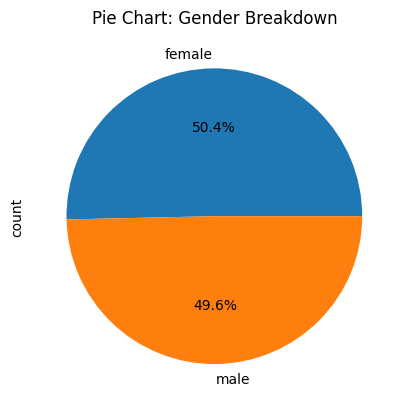

In [3]:
df["Gender"].value_counts().plot(
    kind="pie", autopct="%1.1f%%", title="Pie Chart: Gender Breakdown"
)
plt.show()

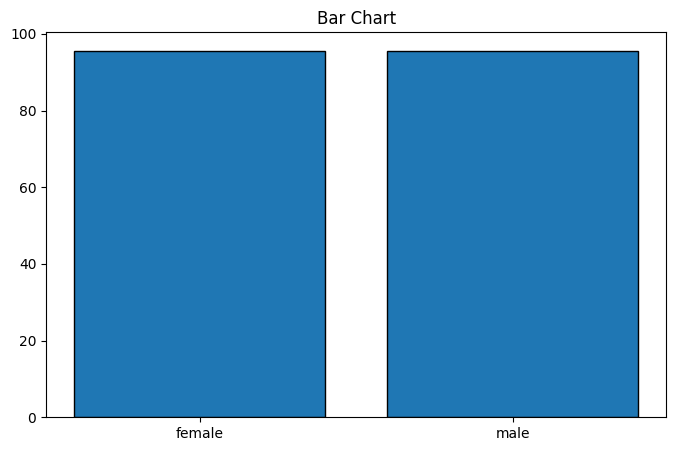

In [4]:
avg_hr_by_gender = df.groupby("Gender")["Heart_Rate"].mean()
plt.figure(figsize=(8, 5))
plt.bar(avg_hr_by_gender.index, avg_hr_by_gender.values, edgecolor="black")
plt.title("Bar Chart")
plt.show()

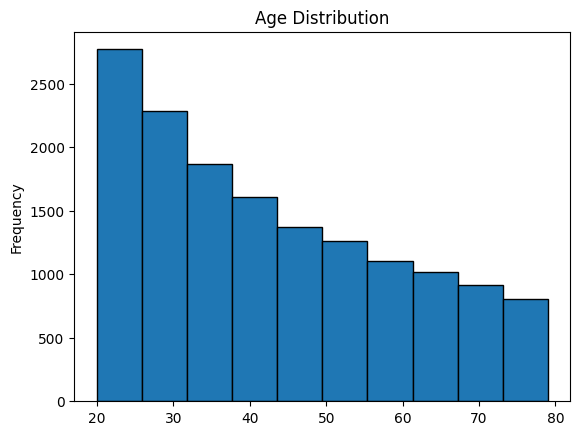

In [7]:
df["Age"].plot(kind="hist", title="Age Distribution", edgecolor="black")
plt.show()

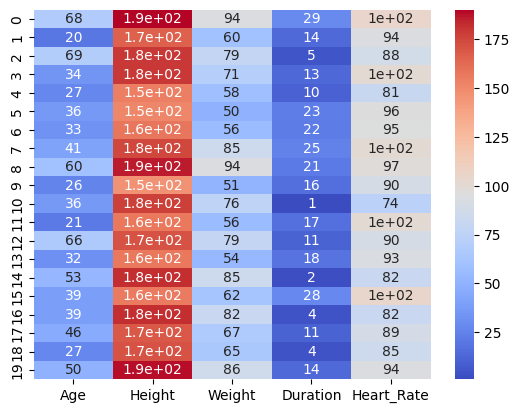

In [6]:
sns.heatmap(
    df[["Age", "Height", "Weight", "Duration", "Heart_Rate"]].head(20),
    annot=True,
    cmap="coolwarm",
)
plt.show()

In [5]:
import plotly.express as px

df["Country"] = np.random.choice(
    ["USA", "CAN", "GBR", "AUS", "FRA", "DEU", "IND"], size=len(df)
)
geo_df = df.groupby("Country")["Duration"].mean().reset_index()

fig = px.choropleth(
    geo_df,
    locations="Country",
    color="Duration",
    hover_name="Country",
    color_continuous_scale=px.colors.sequential.Plasma,
    title="Average Workout Duration by Country",
)
fig.show()

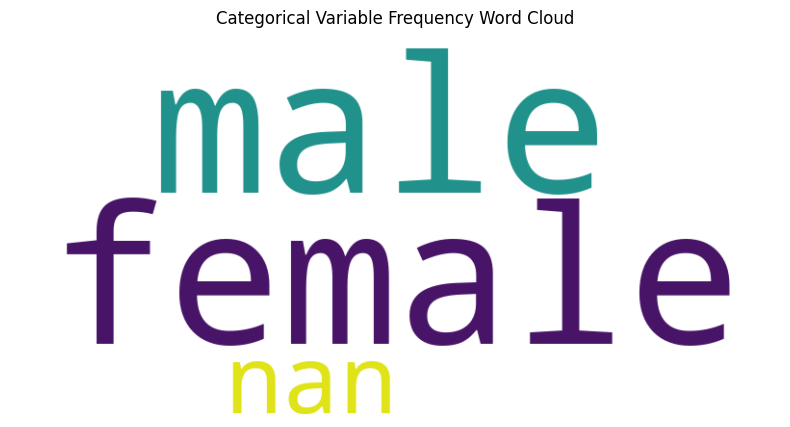

In [8]:
from wordcloud import WordCloud

text_data = " ".join(df["Gender"].astype(str))
wordcloud = WordCloud(
    width=800, height=400, background_color="white"
).generate(text_data)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Categorical Variable Frequency Word Cloud")
plt.show()

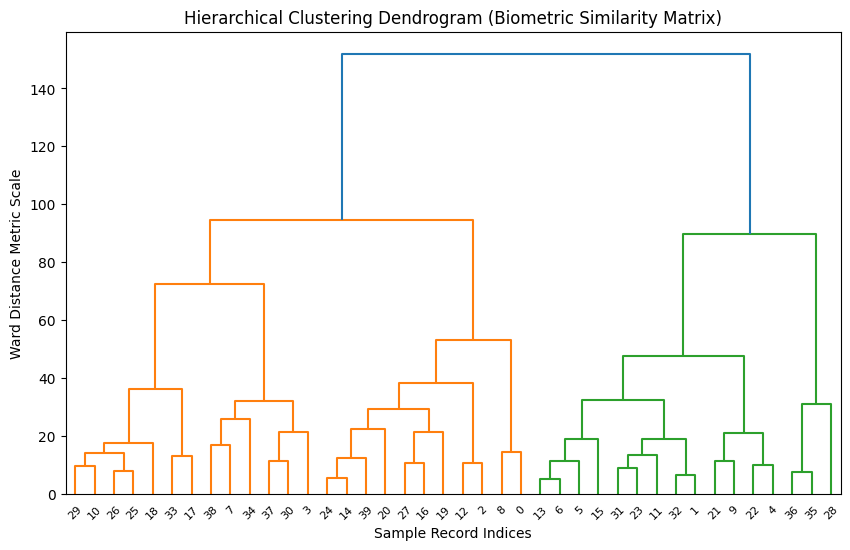

In [9]:
from scipy.cluster.hierarchy import dendrogram, linkage

cluster_features = df[["Age", "Height", "Weight", "Duration", "Heart_Rate"]].head(
    40
)
linked = linkage(cluster_features, method="ward")

plt.figure(figsize=(10, 6))
dendrogram(
    linked,
    orientation="top",
    distance_sort="descending",
    show_leaf_counts=True,
)
plt.title("Hierarchical Clustering Dendrogram (Biometric Similarity Matrix)")
plt.xlabel("Sample Record Indices")
plt.ylabel("Ward Distance Metric Scale")
plt.show()

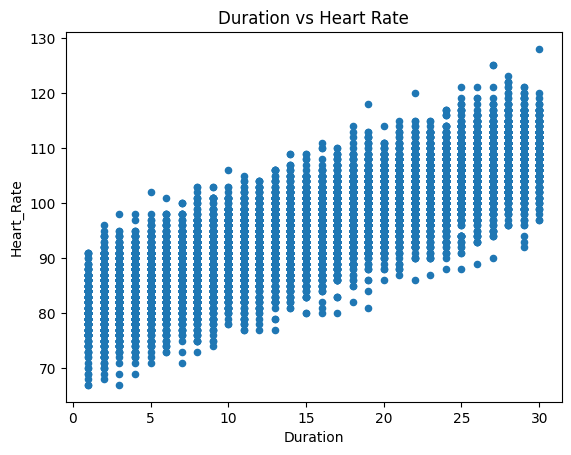

In [10]:
df.plot(
    kind="scatter", x="Duration", y="Heart_Rate", title="Duration vs Heart Rate"
)
plt.show()

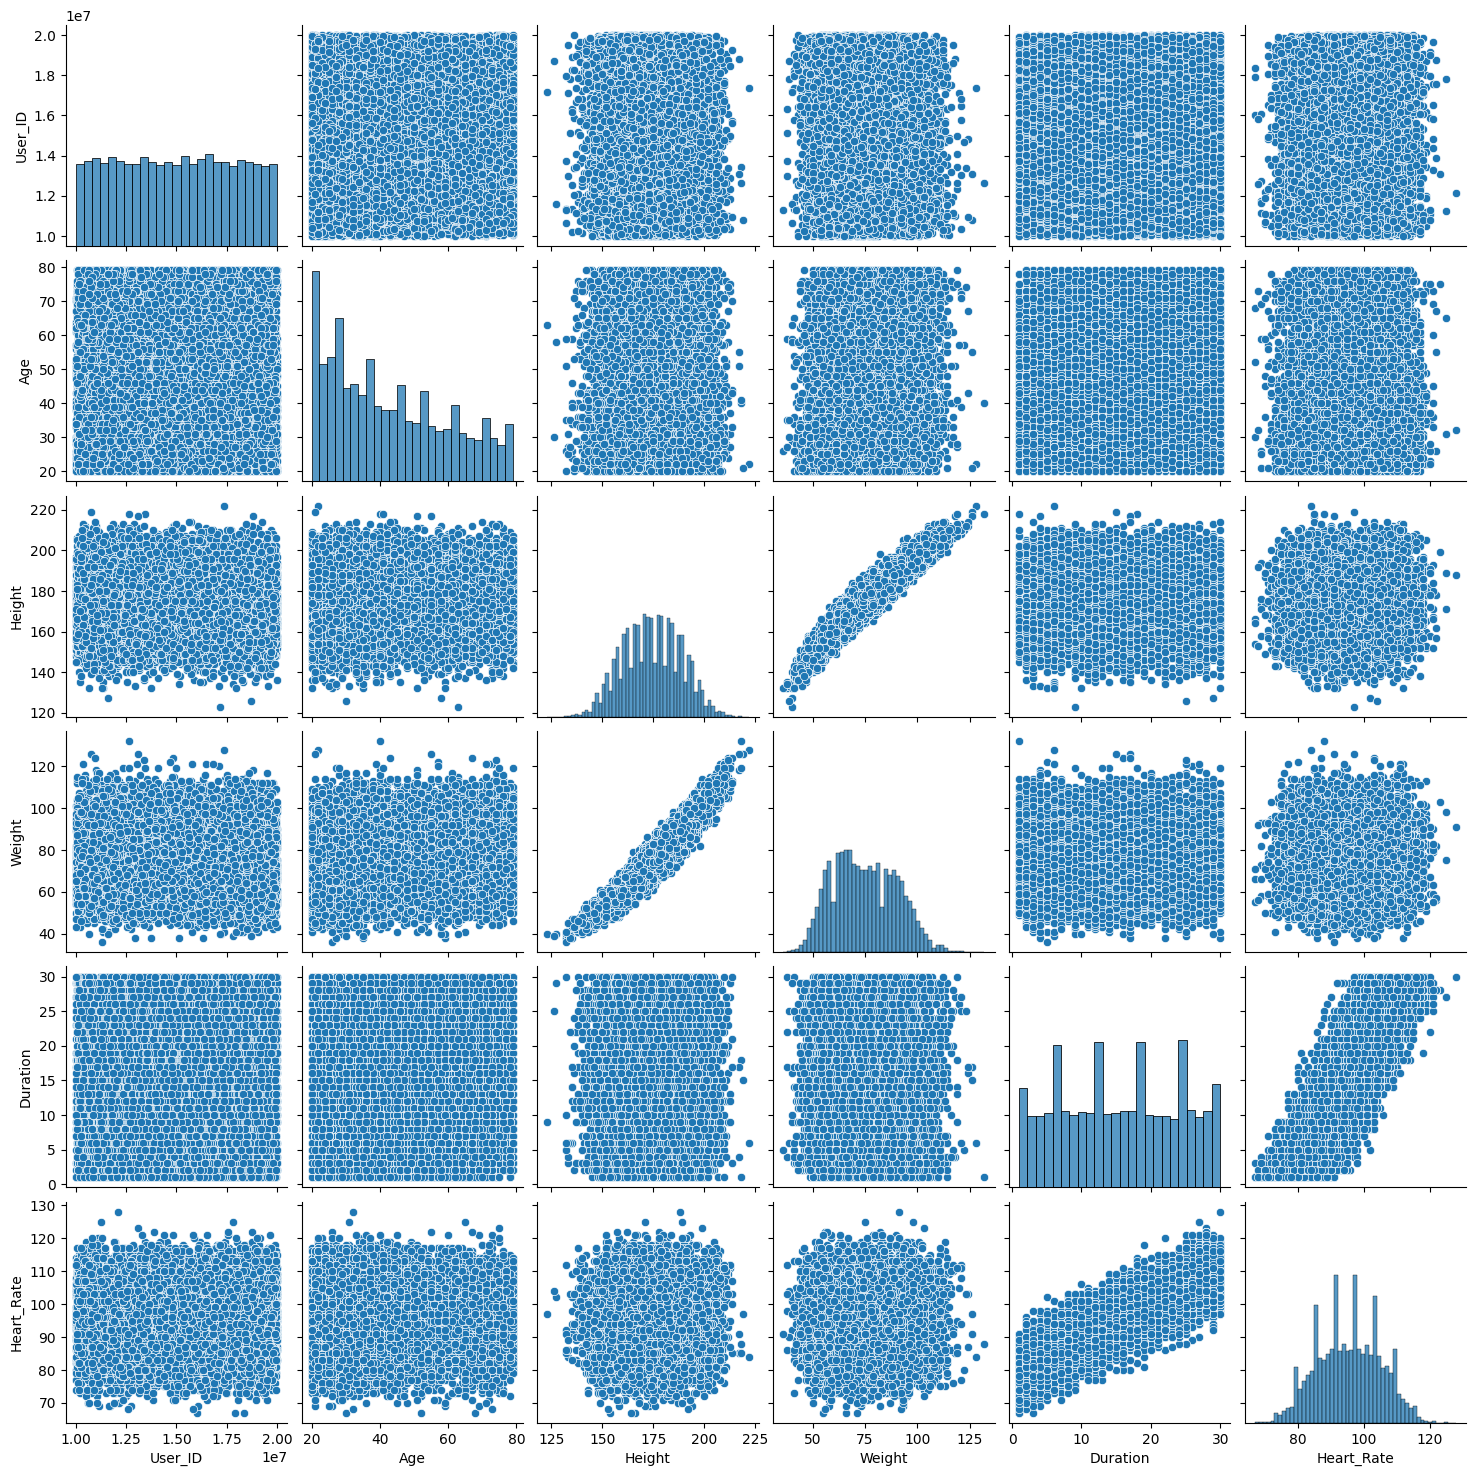

In [11]:
sns.pairplot(df)
plt.show()

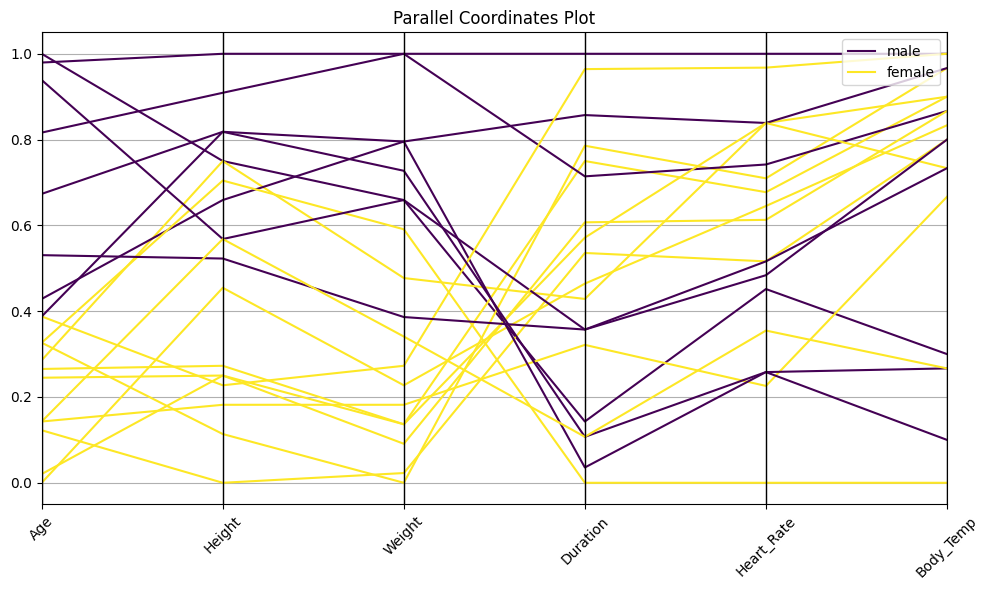

In [12]:
import io

data_string = """User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
14733363,male,68,190,94,29,105,40.8
14861698,female,20,166,60,14,94,40.3
11179863,male,69,179,79,5,88,38.7
16180408,female,34,179,71,13,100,40.5
17771927,female,27,154,58,10,81,39.8
15130815,female,36,151,50,23,96,40.7
19602372,female,33,158,56,22,95,40.5
11111708,male,41,175,85,25,100,40.7
12132339,male,60,186,94,21,97,40.4
17964668,female,26,146,51,16,90,40.2
13723164,female,36,177,76,1,74,37.8
13681290,female,21,157,56,17,100,40
15566424,male,66,171,79,11,90,40
12891699,female,32,157,54,18,93,40.4
13823829,male,53,182,85,2,82,38.1
17557348,female,39,156,62,28,104,40.8
12198133,male,39,182,82,4,82,38.6
15236104,male,46,169,67,11,89,40.2
11042324,female,27,171,65,4,85,38.6
16864285,male,50,188,86,14,94,?"""

df = pd.read_csv(
    io.StringIO(data_string), na_values=["?", "NA", "N/A", "null"]
)
df = df.dropna().reset_index(drop=True)

numeric_cols = [
    "Age",
    "Height",
    "Weight",
    "Duration",
    "Heart_Rate",
    "Body_Temp",
]
df_norm = df.copy()
df_norm[numeric_cols] = (df_norm[numeric_cols] - df_norm[numeric_cols].min()) / (
    df_norm[numeric_cols].max() - df_norm[numeric_cols].min()
)

plt.figure(figsize=(10, 6))
pd.plotting.parallel_coordinates(
    df_norm[numeric_cols + ["Gender"]], class_column="Gender", colormap="viridis"
)
plt.title("Parallel Coordinates Plot")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

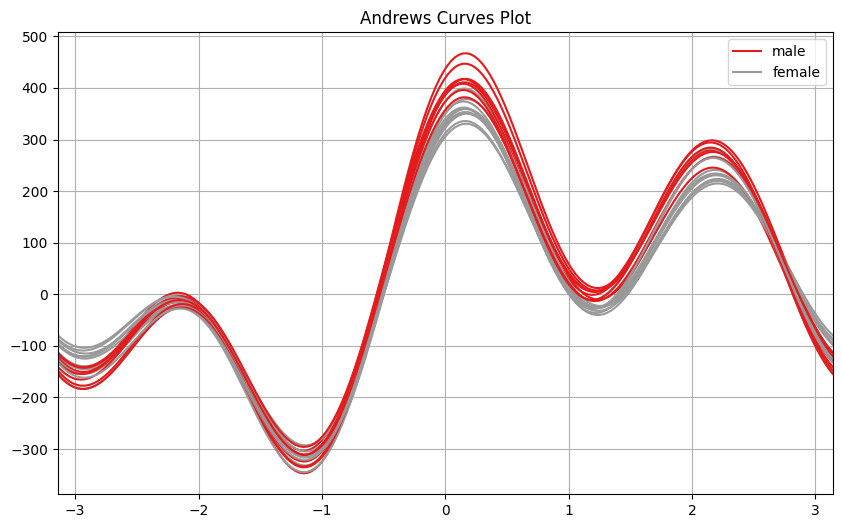

In [13]:
plt.figure(figsize=(10, 6))
pd.plotting.andrews_curves(
    df[numeric_cols + ["Gender"]], "Gender", colormap="Set1"
)
plt.title("Andrews Curves Plot")
plt.show()